# Titanic - Machine Learning from Disaster
## model_experiment.ipynb

In [20]:
!pip install mlflow category_encoders dagshub scikit-learn --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
import os
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

import category_encoders as ce
import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## MLflow / DagsHub Setup

In [22]:
USE_DAGSHUB = True

DAGSHUB_USERNAME = "konstantine25b"
DAGSHUB_REPO     = "titanic-for-tutoring"
DAGSHUB_TOKEN    = "2eaae1414498f697a730998443323fc67f26b842"

if USE_DAGSHUB:
    os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
    os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
    tracking_uri = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
    mlflow.set_tracking_uri(tracking_uri)
else:
    mlflow.set_tracking_uri("mlruns")

EXPERIMENT_NAME = "titanic-experiments"
mlflow.set_experiment(EXPERIMENT_NAME)
print("Tracking URI:", mlflow.get_tracking_uri())

2026/03/28 14:23:15 INFO mlflow.tracking.fluent: Experiment with name 'titanic-experiments' does not exist. Creating a new experiment.


Tracking URI: https://dagshub.com/konstantine25b/titanic-for-tutoring.mlflow


## Data Loading

In [23]:
train_raw = pd.read_csv("data/train_data.csv", index_col=0)
test_raw  = pd.read_csv("data/test_data.csv",  index_col=0)

print("Train shape:", train_raw.shape)
print("Test shape: ", test_raw.shape)
train_raw.head()

Train shape: (792, 16)
Test shape:  (100, 16)


,PassengerId,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,1,0,1,0.2750,0.014151,0,0,1,0.1,1,0,0,0,0,0,1
1,2,1,0,0.4750,0.139136,1,0,0,0.1,1,0,0,0,1,0,0
2,3,1,0,0.3250,0.015469,0,0,1,0.0,0,0,0,1,0,0,1
3,4,1,0,0.4375,0.103644,1,0,0,0.1,1,0,0,0,0,0,1
4,5,0,1,0.4375,0.015713,0,0,1,0.0,1,0,0,0,0,0,1


In [24]:
print("Columns:", train_raw.columns.tolist())
print("\nMissing values:")
print(train_raw.isnull().sum())

Columns: ['PassengerId', 'Survived', 'Sex', 'Age', 'Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Family_size', 'Title_1', 'Title_2', 'Title_3', 'Title_4', 'Emb_1', 'Emb_2', 'Emb_3']

Missing values:
PassengerId    0
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64


## Train / Validation Split

Split before encoding so all encoders (WOE, OHE) are fit only on training data.

In [25]:
TARGET      = 'Survived'
VAL_SIZE    = 0.2
RANDOM_SEED = 42

train_split, val_split = train_test_split(
    train_raw,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=train_raw[TARGET]
)

train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)

print(f"Train split: {train_split.shape}  |  Val split: {val_split.shape}")
print(f"Survival rate — train: {train_split[TARGET].mean():.3f}  val: {val_split[TARGET].mean():.3f}")

Train split: (633, 16)  |  Val split: (159, 16)
Survival rate — train: 0.387  val: 0.384


---
# Data Cleaning

The dataset is already pre-processed (normalized Age/Fare, OHE-encoded Pclass/Title/Embarked).  
Cleaning step: drop PassengerId, check for nulls, remove duplicates, verify dtypes.

In [26]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.drop(columns=['PassengerId'], errors='ignore', inplace=True)
    df.drop_duplicates(inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)
    return df.reset_index(drop=True)


train_clean = clean(train_split)
val_clean   = clean(val_split)
test_clean  = clean(test_raw)

print("After cleaning — train:", train_clean.shape, "  val:", val_clean.shape)
print("Remaining nulls:")
print(train_clean.isnull().sum())
train_clean.head()

After cleaning — train: (571, 15)   val: (148, 15)
Remaining nulls:
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64


,Survived,Sex,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Family_size,Title_1,Title_2,Title_3,Title_4,Emb_1,Emb_2,Emb_3
0,1,0,0.3750,0.168837,1,0,0,0.0,0,0,0,1,0,0,1
1,0,1,0.4250,0.040989,0,1,0,0.1,1,0,0,0,0,0,1
2,0,0,0.6250,0.056043,1,0,0,0.0,0,0,0,1,1,0,0
3,1,0,0.3000,0.028302,0,1,0,0.2,1,0,0,0,0,0,1
4,0,1,0.2375,0.103644,1,0,0,0.1,1,0,0,0,0,0,1


---
# Feature Engineering

The dataset carries OHE columns (Pclass_1/2/3, Title_1-4, Emb_1-3).  
We reconstruct the original categorical labels so we can apply OHE and WOE from scratch.  
Additional features: `IsAlone` from `Family_size`, and quantile bins for Age and Fare.

In [27]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['Pclass']   = (df[['Pclass_1','Pclass_2','Pclass_3']]
                      .idxmax(axis=1)
                      .str.replace('Pclass_', '', regex=False)
                      .astype(int))

    df['Title']    = (df[['Title_1','Title_2','Title_3','Title_4']]
                      .idxmax(axis=1)
                      .str.replace('Title_', '', regex=False)
                      .astype(int))

    df['Embarked'] = (df[['Emb_1','Emb_2','Emb_3']]
                      .idxmax(axis=1)
                      .str.replace('Emb_', '', regex=False)
                      .astype(int))

    df['IsAlone']  = (df['Family_size'] == 0).astype(int)

    df.drop(columns=['Pclass_1','Pclass_2','Pclass_3',
                     'Title_1','Title_2','Title_3','Title_4',
                     'Emb_1','Emb_2','Emb_3'], inplace=True)

    return df


train_fe = add_features(train_clean)
val_fe   = add_features(val_clean)
test_fe  = add_features(test_clean)

print("Features after engineering:", train_fe.columns.tolist())
train_fe.head()

Features after engineering: ['Survived', 'Sex', 'Age', 'Fare', 'Family_size', 'Pclass', 'Title', 'Embarked', 'IsAlone', 'AgeBin', 'FareBin']


,Survived,Sex,Age,Fare,Family_size,Pclass,Title,Embarked,IsAlone,AgeBin,FareBin
0,1,0,0.3750,0.168837,0.0,1,4,3,1,Q3,Q4
1,0,1,0.4250,0.040989,0.1,2,1,3,0,Q3,Q3
2,0,0,0.6250,0.056043,0.0,1,4,1,1,Q4,Q3
3,1,0,0.3000,0.028302,0.2,2,1,3,0,Q2,Q2
4,0,1,0.2375,0.103644,0.1,1,1,3,0,Q1,Q4


## One-Hot Encoding (OHE)

Categories learned from **train only**. Val and test aligned via `reindex`.

In [28]:
TARGET       = 'Survived'
CAT_COLS     = ['Sex', 'Pclass', 'Title', 'Embarked']
NUMERIC_COLS = ['Age', 'Fare', 'Family_size', 'IsAlone']


def apply_ohe(train_df: pd.DataFrame, other_dfs: list, cols: list):
    train_dummies = pd.get_dummies(train_df[cols].astype(str), columns=cols, drop_first=False)
    ohe_columns   = train_dummies.columns.tolist()
    results       = [train_dummies.reset_index(drop=True)]
    for df in other_dfs:
        dummies = pd.get_dummies(df[cols].astype(str), columns=cols, drop_first=False)
        results.append(dummies.reindex(columns=ohe_columns, fill_value=0).reset_index(drop=True))
    return results


y_train = train_fe[TARGET].reset_index(drop=True)
y_val   = val_fe[TARGET].reset_index(drop=True)

ohe_parts = apply_ohe(train_fe, [val_fe, test_fe], CAT_COLS)
ohe_tr, ohe_vl, ohe_te = ohe_parts

X_ohe_train = pd.concat([train_fe[NUMERIC_COLS].reset_index(drop=True), ohe_tr], axis=1)
X_ohe_val   = pd.concat([val_fe[NUMERIC_COLS].reset_index(drop=True),   ohe_vl], axis=1)
X_ohe_test  = pd.concat([test_fe[NUMERIC_COLS].reset_index(drop=True),  ohe_te], axis=1)

print('OHE train shape:', X_ohe_train.shape, ' val:', X_ohe_val.shape)
X_ohe_train.head()

OHE train shape: (571, 24)  val: (148, 24)


,Age,Fare,Family_size,IsAlone,Sex_0,Sex_1,Pclass_1,Pclass_2,Pclass_3,Title_1,Title_2,Title_3,Title_4,Embarked_1,Embarked_2,Embarked_3,AgeBin_Q1,AgeBin_Q2,AgeBin_Q3,AgeBin_Q4,FareBin_Q1,FareBin_Q2,FareBin_Q3,FareBin_Q4
0,0.3750,0.168837,0.0,1,True,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True
1,0.4250,0.040989,0.1,0,False,True,False,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,False
2,0.6250,0.056043,0.0,1,True,False,True,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,True,False
3,0.3000,0.028302,0.2,0,True,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False,False
4,0.2375,0.103644,0.1,0,False,True,True,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,True


## Weight of Evidence (WOE) Encoding

Encoder fit on **train only**, then applied to val and test.  
WOE = ln(P(X|Y=1) / P(X|Y=0)) — natural for binary classification.

In [12]:
WOE_COLS = ['Sex', 'Pclass', 'Title', 'Embarked']

woe_encoder = ce.WOEEncoder(cols=WOE_COLS, regularization=1.0)


def prep_woe(df: pd.DataFrame) -> pd.DataFrame:
    return df[NUMERIC_COLS + WOE_COLS].copy().reset_index(drop=True)


woe_encoder.fit(prep_woe(train_fe), y_train)

X_woe_train = woe_encoder.transform(prep_woe(train_fe))
X_woe_val   = woe_encoder.transform(prep_woe(val_fe))
X_woe_test  = woe_encoder.transform(prep_woe(test_fe))

print('WOE train shape:', X_woe_train.shape, ' val:', X_woe_val.shape)
X_woe_train.head()

WOE train shape: (571, 10)  val: (148, 10)


,Age,Fare,Family_size,IsAlone,Sex,Pclass,Title,Embarked,AgeBin,FareBin
0,0.3750,0.168837,0.0,1,1.461780,0.845700,1.303669,-0.146548,0.174051,0.832645
1,0.4250,0.040989,0.1,0,-0.982567,0.384864,-0.412340,-0.146548,0.174051,0.241527
2,0.6250,0.056043,0.0,1,1.461780,0.845700,1.303669,0.561251,-0.168033,0.241527
3,0.3000,0.028302,0.2,0,1.461780,0.384864,-0.412340,-0.146548,-0.096730,-0.377854
4,0.2375,0.103644,0.1,0,-0.982567,0.845700,-0.412340,-0.146548,0.129219,0.832645


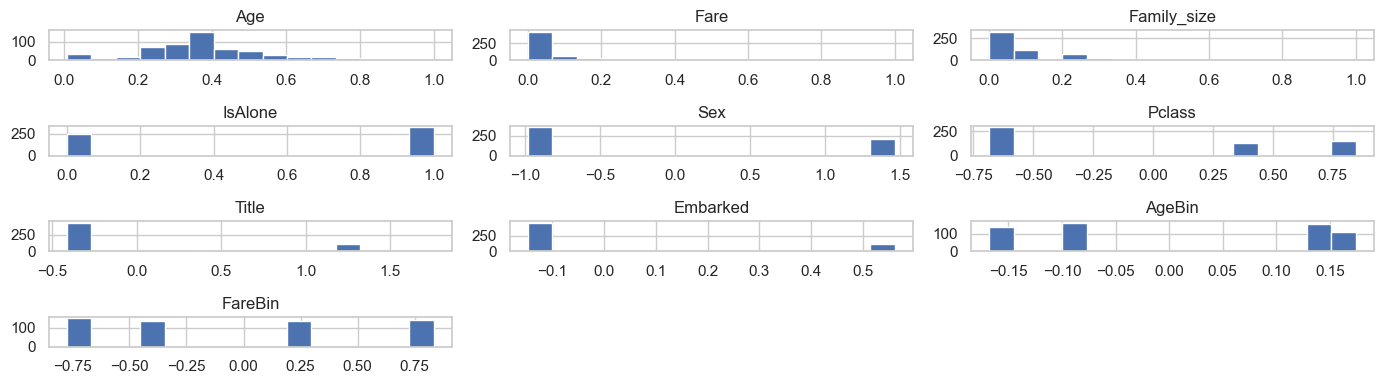

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
X_ohe_train.iloc[:, :10].hist(ax=axes[0], bins=15)
axes[0].set_title('OHE Feature Distributions (train, first 10 cols)')
X_woe_train.hist(ax=axes[1], bins=15)
axes[1].set_title('WOE Feature Distributions (train)')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=80)
plt.show()

---
# Feature Selection
## Recursive Feature Elimination (RFE)

Fit on **train split only**.


[OHE] Selected 15 features:
['Age', 'Fare', 'Family_size', 'Sex_0', 'Sex_1', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Title_1', 'Title_4', 'Embarked_3', 'AgeBin_Q2', 'AgeBin_Q3', 'FareBin_Q2', 'FareBin_Q4']


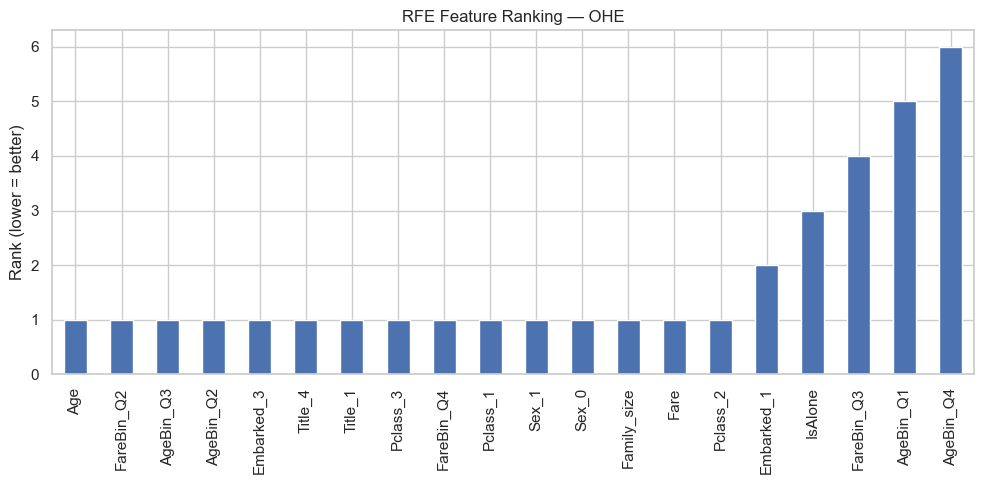


[WOE] Selected 8 features:
['Age', 'Fare', 'Family_size', 'Sex', 'Pclass', 'Title', 'AgeBin', 'FareBin']


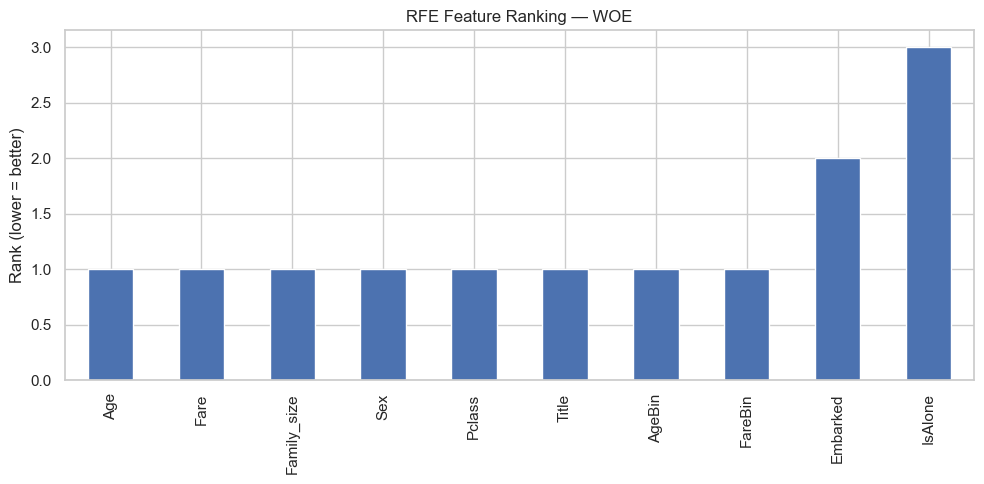

In [14]:
def run_rfe(X_tr: pd.DataFrame, y_tr: pd.Series, n_features: int, label: str):
    estimator = RandomForestClassifier(n_estimators=100, random_state=42)
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(X_tr.values.astype(float))
    rfe       = RFE(estimator=estimator, n_features_to_select=n_features, step=1)
    rfe.fit(X_scaled, y_tr)
    selected  = X_tr.columns[rfe.support_].tolist()
    ranking   = pd.Series(rfe.ranking_, index=X_tr.columns).sort_values()

    print(f"\n[{label}] Selected {n_features} features:")
    print(selected)

    plt.figure(figsize=(10, 5))
    ranking.head(n_features + 5).plot(kind='bar')
    plt.title(f'RFE Feature Ranking — {label}')
    plt.ylabel('Rank (lower = better)')
    plt.tight_layout()
    plt.savefig(f'rfe_ranking_{label}.png', dpi=80)
    plt.show()

    return selected


N_FEATURES_OHE = min(15, X_ohe_train.shape[1])
N_FEATURES_WOE = min(8,  X_woe_train.shape[1])

selected_ohe = run_rfe(X_ohe_train, y_train, N_FEATURES_OHE, 'OHE')
selected_woe = run_rfe(X_woe_train, y_train, N_FEATURES_WOE, 'WOE')

In [15]:
X_ohe_tr_sel   = X_ohe_train[selected_ohe]
X_ohe_val_sel  = X_ohe_val[selected_ohe]
X_ohe_test_sel = X_ohe_test[selected_ohe]

X_woe_tr_sel   = X_woe_train[selected_woe]
X_woe_val_sel  = X_woe_val[selected_woe]
X_woe_test_sel = X_woe_test[selected_woe]

print("OHE — train:", X_ohe_tr_sel.shape, " val:", X_ohe_val_sel.shape)
print("WOE — train:", X_woe_tr_sel.shape, " val:", X_woe_val_sel.shape)

OHE — train: (571, 15)  val: (148, 15)
WOE — train: (571, 8)  val: (148, 8)


---
# Training

Each run logs: params, CV metrics (train split), val metrics (held-out val), confusion matrix, ROC curve, feature importance.

In [16]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def log_run(
    run_name: str,
    model,
    X_tr: pd.DataFrame,
    y_tr: pd.Series,
    X_vl: pd.DataFrame,
    y_vl: pd.Series,
    encoding: str,
    extra_params: dict = None,
    register: bool = False,
):
    X_tr_arr = X_tr.values.astype(float)
    X_vl_arr = X_vl.values.astype(float)

    acc_scores = cross_val_score(model, X_tr_arr, y_tr, cv=CV, scoring='accuracy')
    auc_scores = cross_val_score(model, X_tr_arr, y_tr, cv=CV, scoring='roc_auc')
    f1_scores  = cross_val_score(model, X_tr_arr, y_tr, cv=CV, scoring='f1')

    model.fit(X_tr_arr, y_tr)
    y_pred = model.predict(X_vl_arr)
    y_prob = model.predict_proba(X_vl_arr)[:, 1] if hasattr(model, 'predict_proba') else None

    val_auc = roc_auc_score(y_vl, y_prob) if y_prob is not None else 0.0

    with mlflow.start_run(run_name=run_name):
        params = {
            'model':      type(model).__name__,
            'encoding':   encoding,
            'n_features': X_tr.shape[1],
            'val_size':   len(y_vl),
        }
        if extra_params:
            params.update(extra_params)
        mlflow.log_params(params)

        mlflow.log_metrics({
            'cv_acc_mean':  acc_scores.mean(),
            'cv_acc_std':   acc_scores.std(),
            'cv_auc_mean':  auc_scores.mean(),
            'cv_auc_std':   auc_scores.std(),
            'cv_f1_mean':   f1_scores.mean(),
            'cv_f1_std':    f1_scores.std(),
            'val_accuracy': accuracy_score(y_vl, y_pred),
            'val_f1':       f1_score(y_vl, y_pred),
            'val_auc':      val_auc,
        })

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        ConfusionMatrixDisplay(confusion_matrix(y_vl, y_pred)).plot(ax=axes[0], colorbar=False)
        axes[0].set_title('Confusion Matrix (val)')
        if y_prob is not None:
            RocCurveDisplay.from_predictions(y_vl, y_prob, ax=axes[1])
            axes[1].set_title('ROC Curve (val)')
        plt.suptitle(run_name)
        plt.tight_layout()
        plot_path = f'{run_name.replace(" ", "_")}_plots.png'
        plt.savefig(plot_path, dpi=80)
        plt.show()
        mlflow.log_artifact(plot_path)

        if hasattr(model, 'feature_importances_'):
            imp = pd.Series(model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
            fig2, ax2 = plt.subplots(figsize=(10, 4))
            imp.head(15).plot(kind='bar', ax=ax2)
            ax2.set_title(f'Feature Importance — {run_name}')
            plt.tight_layout()
            imp_path = f'{run_name.replace(" ", "_")}_importance.png'
            plt.savefig(imp_path, dpi=80)
            plt.show()
            mlflow.log_artifact(imp_path)

        if register:
            mlflow.sklearn.log_model(
                model, artifact_path='model',
                registered_model_name='titanic-best-model'
            )
        else:
            mlflow.sklearn.log_model(model, artifact_path='model')

        run_id = mlflow.active_run().info.run_id

    print(f"[{run_name}] cv_auc={auc_scores.mean():.4f} val_auc={val_auc:.4f}  run_id={run_id}")
    return {
        'run_name': run_name,
        'run_id':   run_id,
        'cv_acc':   acc_scores.mean(),
        'cv_auc':   auc_scores.mean(),
        'cv_f1':    f1_scores.mean(),
        'val_auc':  val_auc,
        'val_acc':  accuracy_score(y_vl, y_pred),
    }

### Logistic Regression — OHE vs WOE

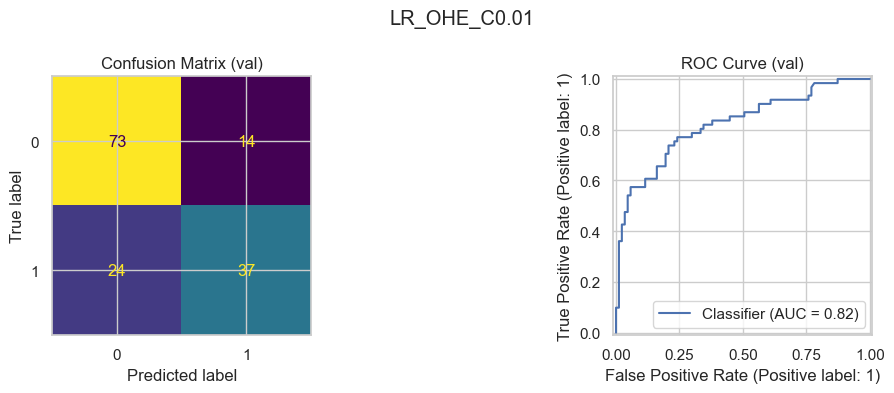

2026/03/28 14:18:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_OHE_C0.01] cv_auc=0.8478 val_auc=0.8220  run_id=854a09573d4a49a5b560ff5806d28d9d


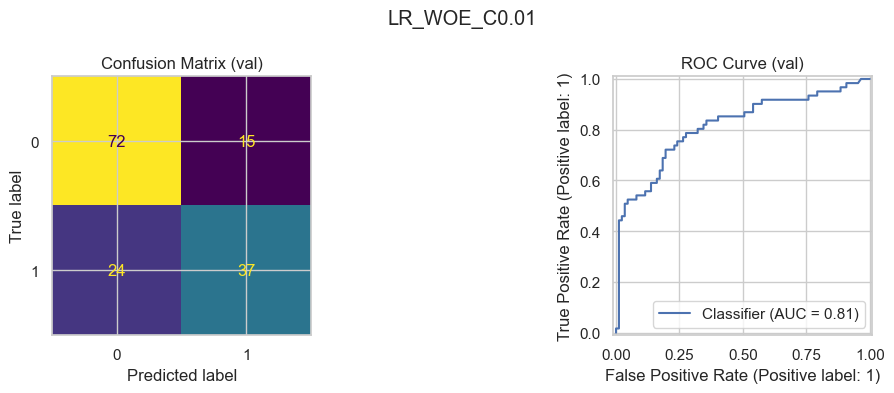

2026/03/28 14:18:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_WOE_C0.01] cv_auc=0.8371 val_auc=0.8149  run_id=16d8399d727f41a89ac68d3ccd25491a


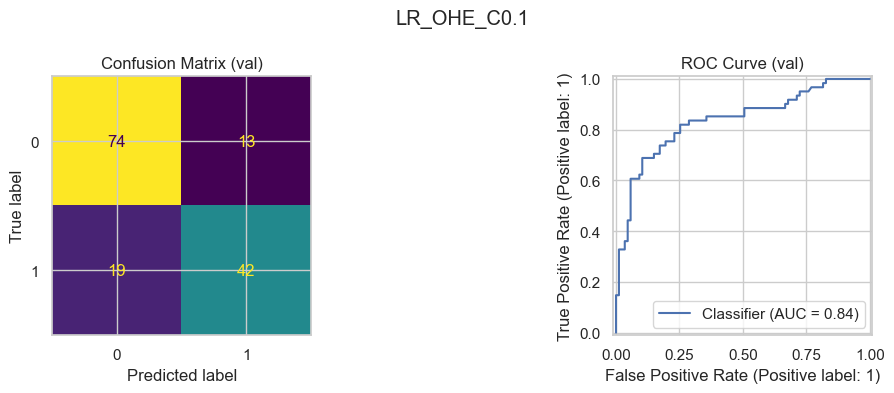

2026/03/28 14:18:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_OHE_C0.1] cv_auc=0.8579 val_auc=0.8360  run_id=5a938168c3024125ad1d753dc8388ba3


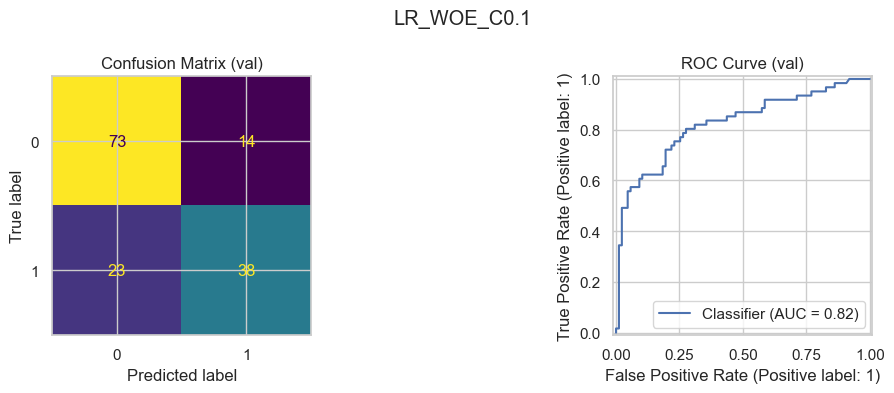

2026/03/28 14:18:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_WOE_C0.1] cv_auc=0.8467 val_auc=0.8235  run_id=8df95ca7afad4bceb912adcf020abab8


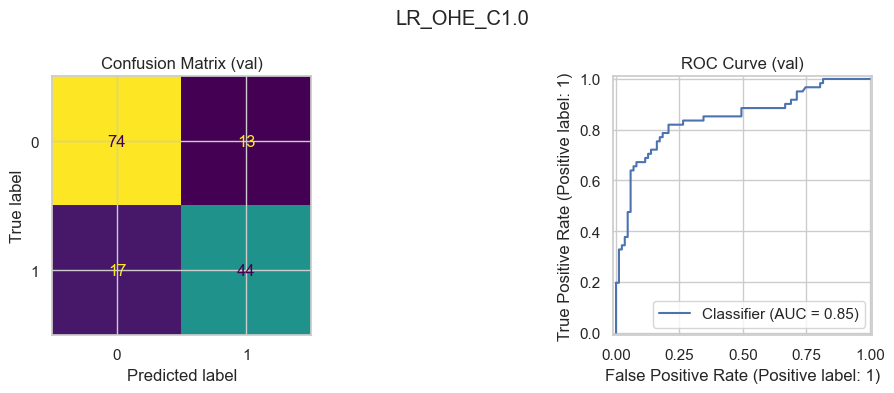

2026/03/28 14:18:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_OHE_C1.0] cv_auc=0.8647 val_auc=0.8460  run_id=ce6aedd1ca734ed28a5fa54973cbf06e


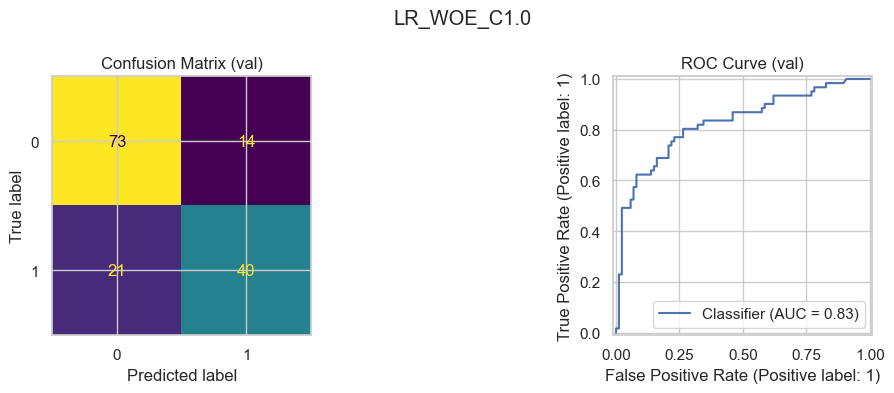

2026/03/28 14:18:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_WOE_C1.0] cv_auc=0.8434 val_auc=0.8269  run_id=dd8043d8888144dbb9c4e63ebad7b39a


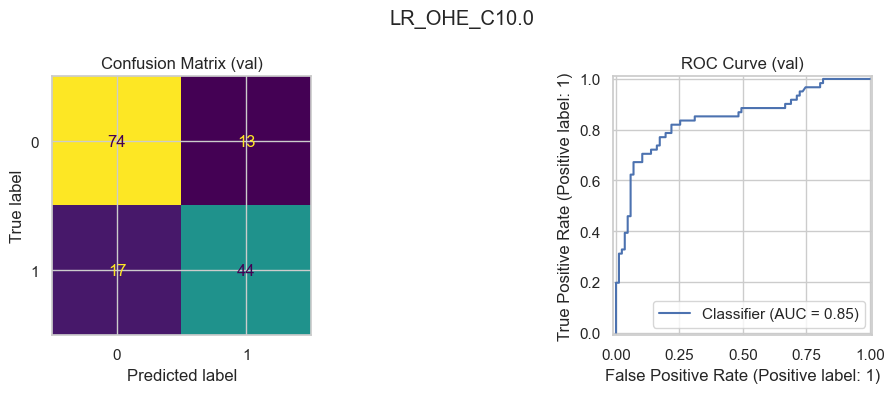

2026/03/28 14:18:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_OHE_C10.0] cv_auc=0.8640 val_auc=0.8461  run_id=01627b552620412fa91d5ad8b8d85b67


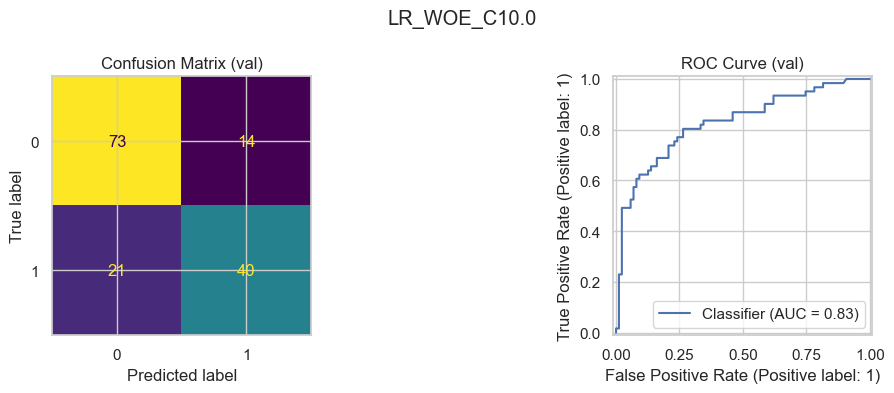

2026/03/28 14:18:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[LR_WOE_C10.0] cv_auc=0.8431 val_auc=0.8269  run_id=65ced66f87b44437a2b57814f0f56543


In [17]:
results = []

for C in [0.01, 0.1, 1.0, 10.0]:
    lr = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=C, max_iter=1000, random_state=42))
    ])
    results.append(log_run(
        f'LR_OHE_C{C}', lr,
        X_ohe_tr_sel, y_train, X_ohe_val_sel, y_val,
        'OHE', extra_params={'C': C}
    ))
    results.append(log_run(
        f'LR_WOE_C{C}', lr,
        X_woe_tr_sel, y_train, X_woe_val_sel, y_val,
        'WOE', extra_params={'C': C}
    ))

### Random Forest — OHE vs WOE

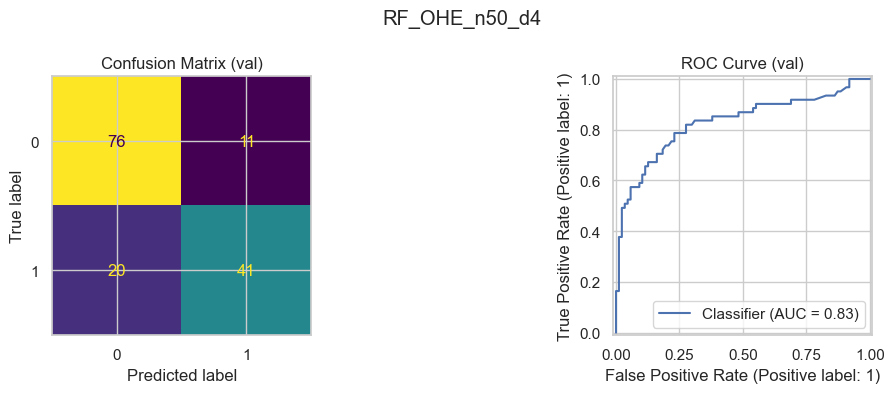

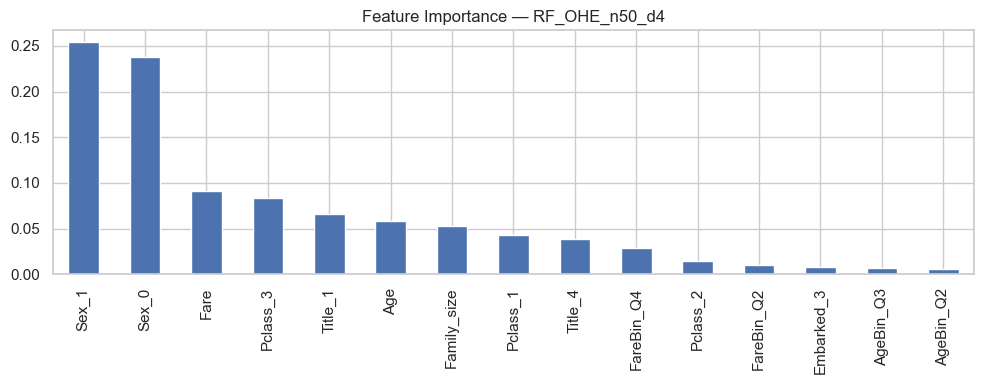

2026/03/28 14:18:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:18:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n50_d4] cv_auc=0.8526 val_auc=0.8280  run_id=6aa09bc7fa51458db9459e1a81af3e32


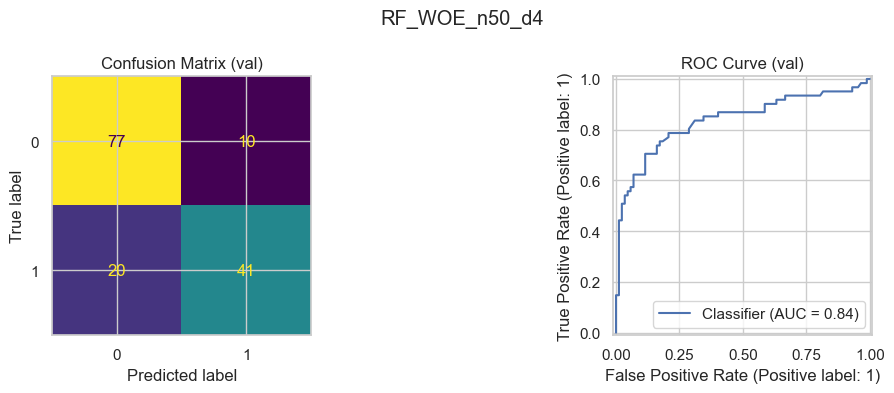

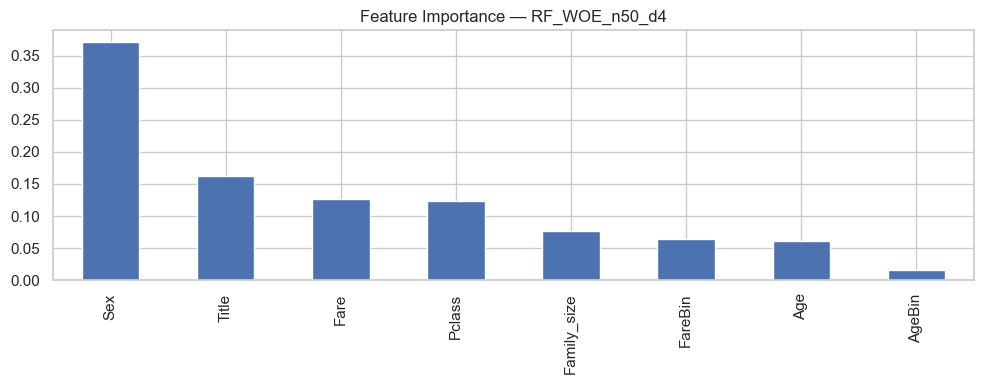

2026/03/28 14:19:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n50_d4] cv_auc=0.8564 val_auc=0.8370  run_id=c5c90c05464c4105a9b04710b514866c


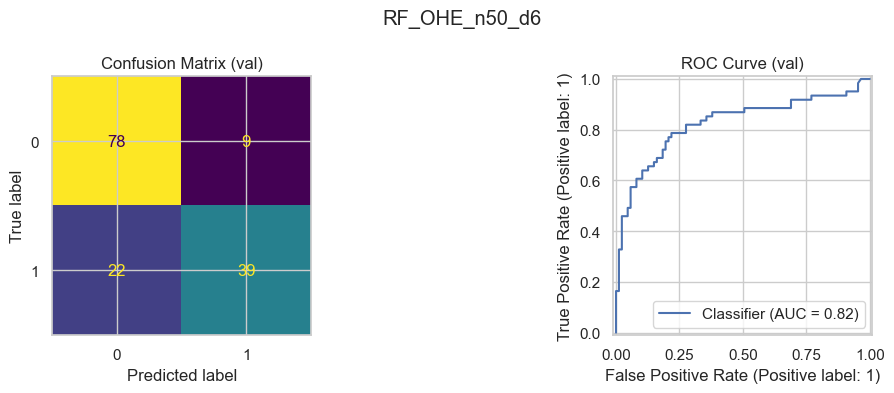

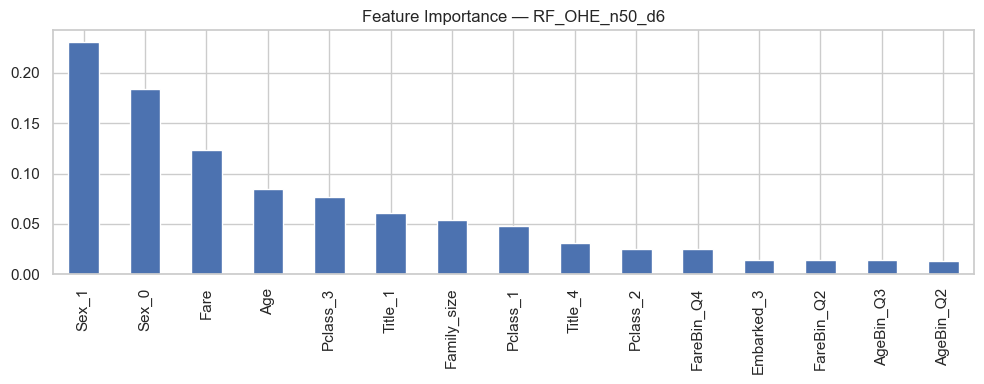

2026/03/28 14:19:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n50_d6] cv_auc=0.8503 val_auc=0.8243  run_id=ffc86ae4fce7487a928eacfa24965d1b


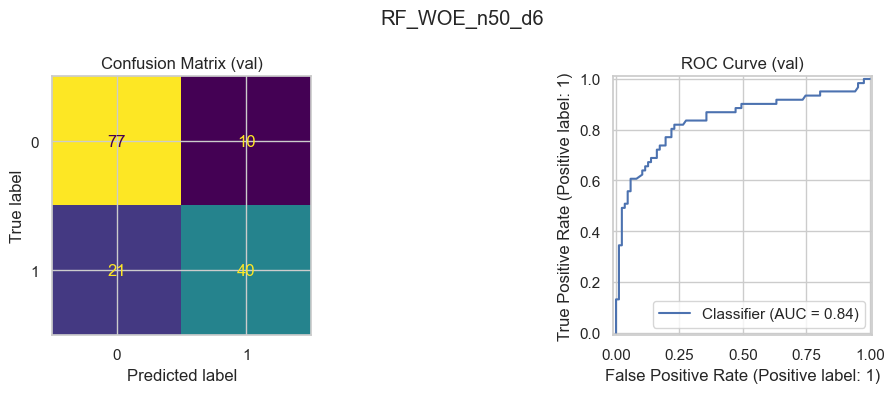

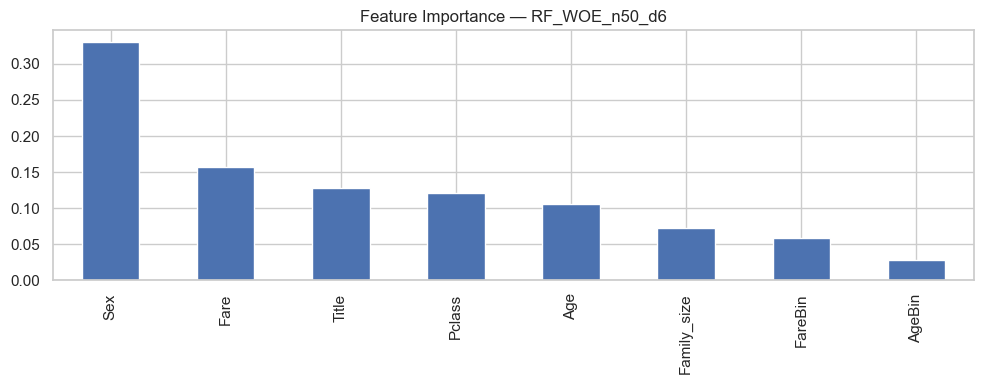

2026/03/28 14:19:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n50_d6] cv_auc=0.8603 val_auc=0.8388  run_id=a7a885f78f404b1b8d9b54ce38aa8f54


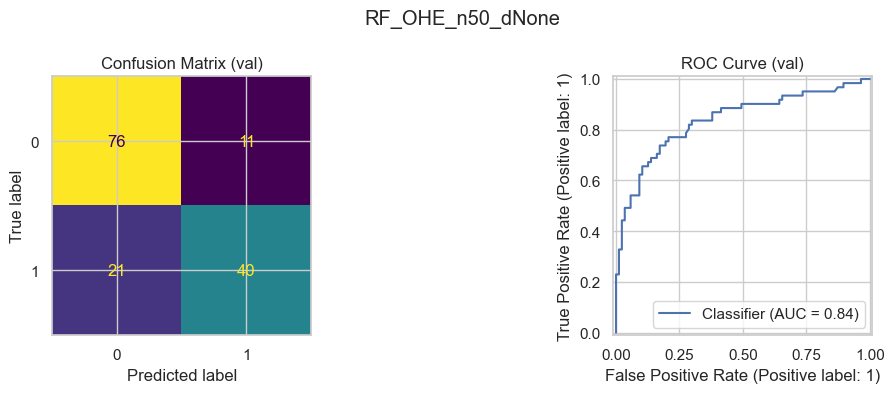

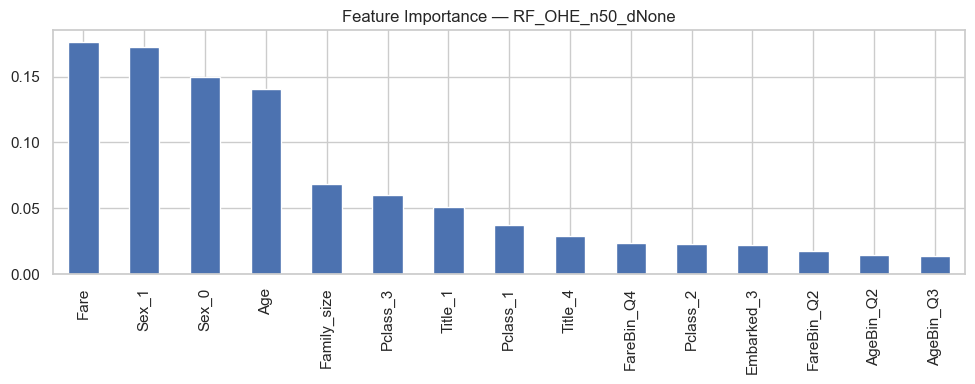

2026/03/28 14:19:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n50_dNone] cv_auc=0.8488 val_auc=0.8374  run_id=321624123e5749f7a6dfd148b49d1355


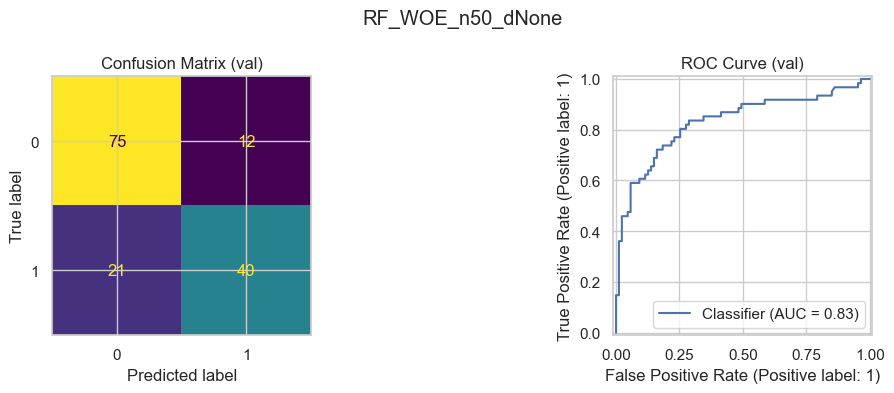

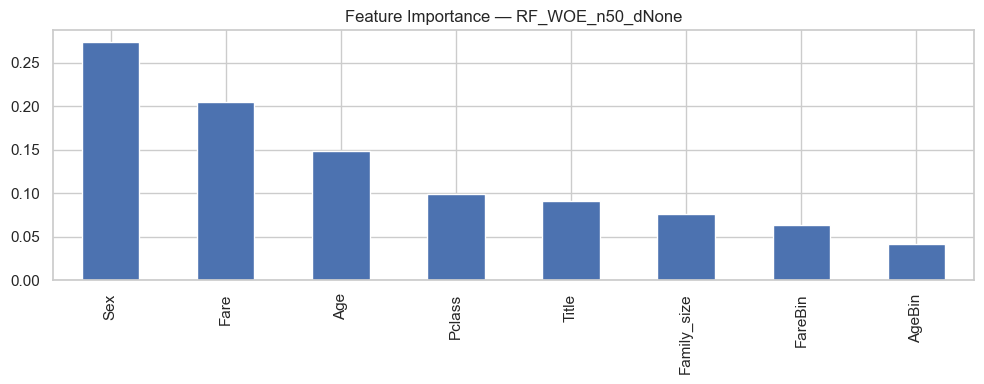

2026/03/28 14:19:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n50_dNone] cv_auc=0.8584 val_auc=0.8316  run_id=17b6d0bc06044061868b6c6ef38f7a25


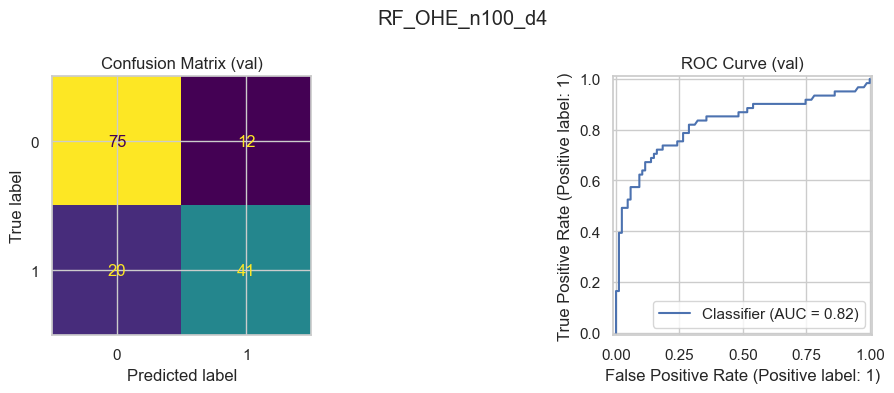

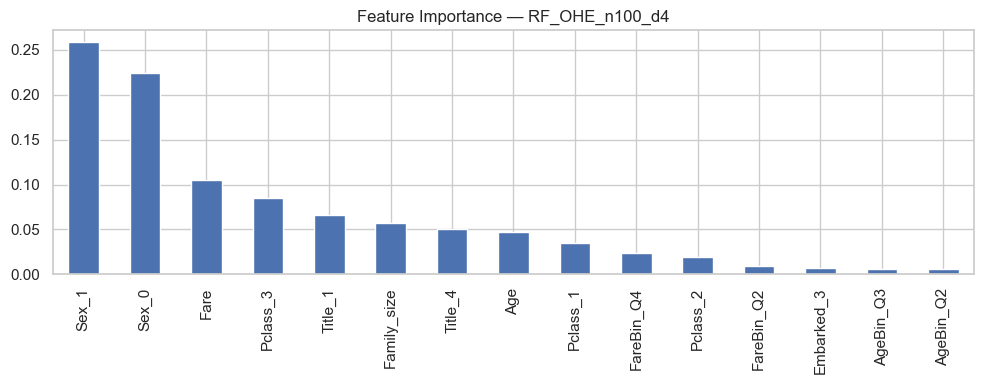

2026/03/28 14:19:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n100_d4] cv_auc=0.8550 val_auc=0.8249  run_id=8e1b9d2f13a04ea382548fa9cef4734b


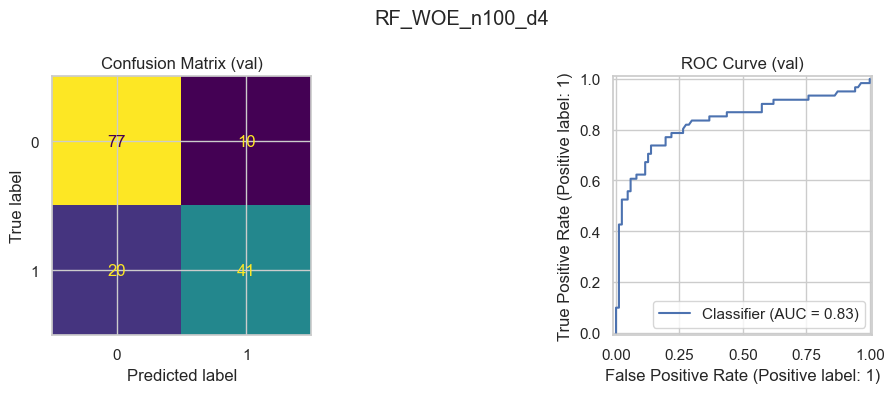

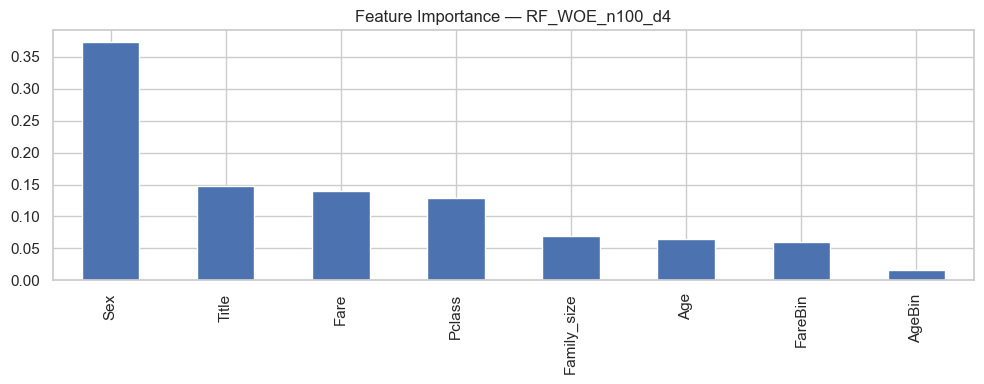

2026/03/28 14:19:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n100_d4] cv_auc=0.8571 val_auc=0.8340  run_id=f508c02bdb1643ceb9c7b66d13009f20


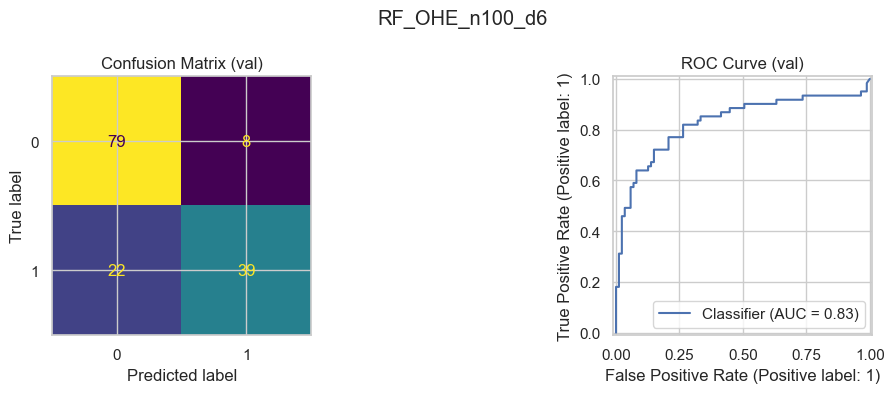

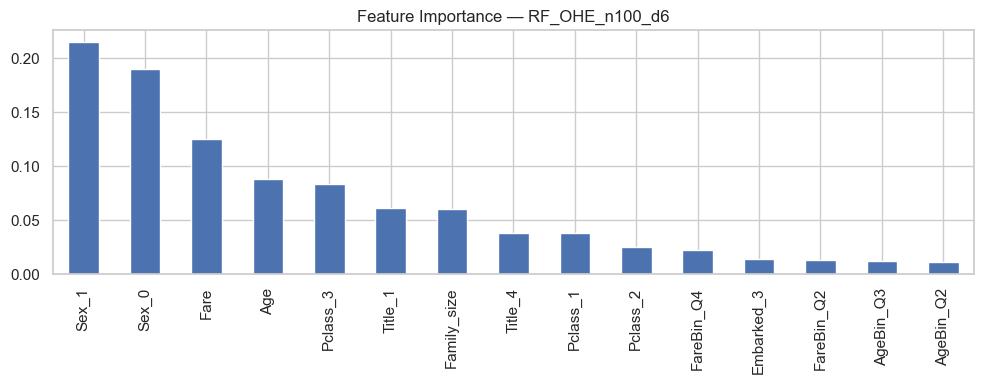

2026/03/28 14:19:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n100_d6] cv_auc=0.8532 val_auc=0.8292  run_id=d3bc7ba731f7426ca61dd3fcfaa29d59


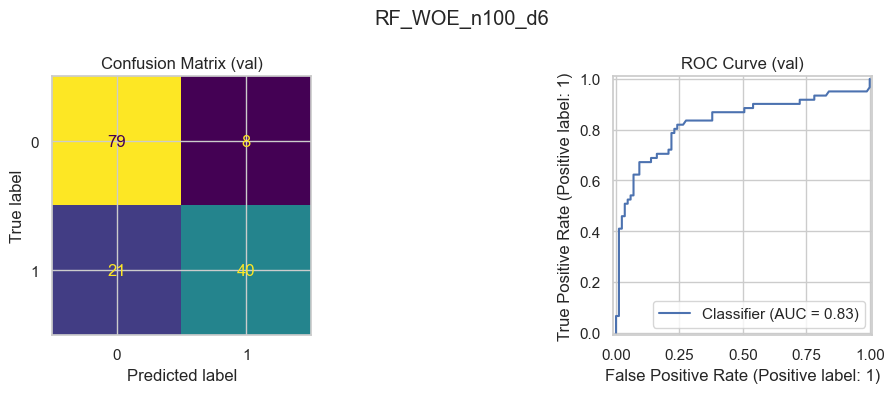

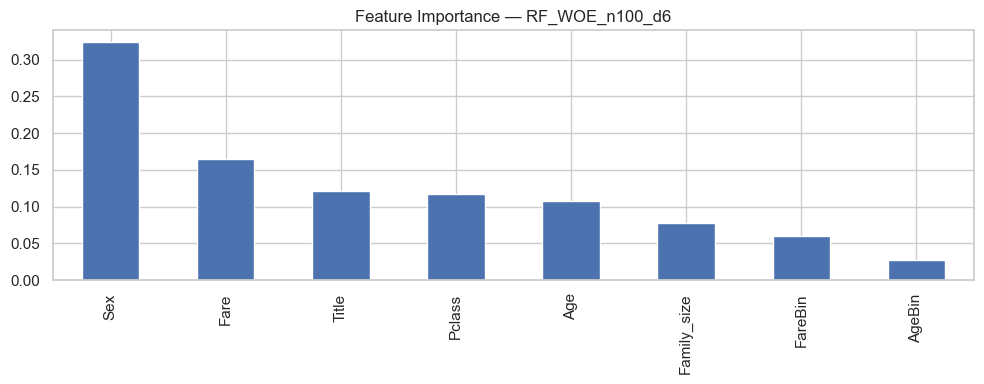

2026/03/28 14:19:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n100_d6] cv_auc=0.8592 val_auc=0.8296  run_id=c70f6e810b6c426b95399c4a5fa67173


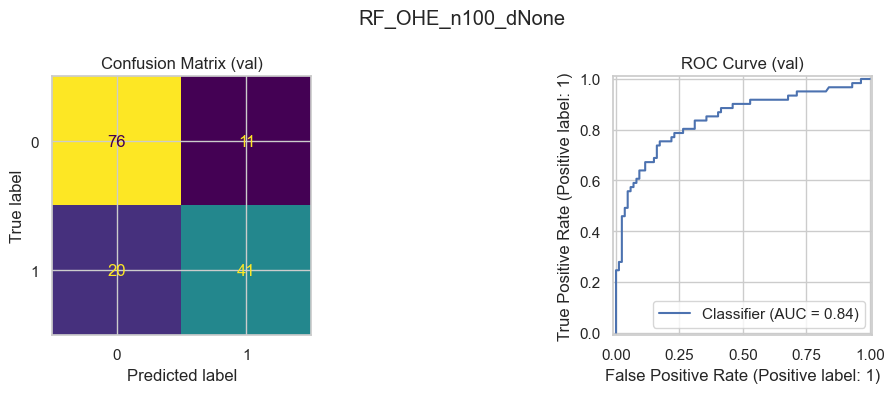

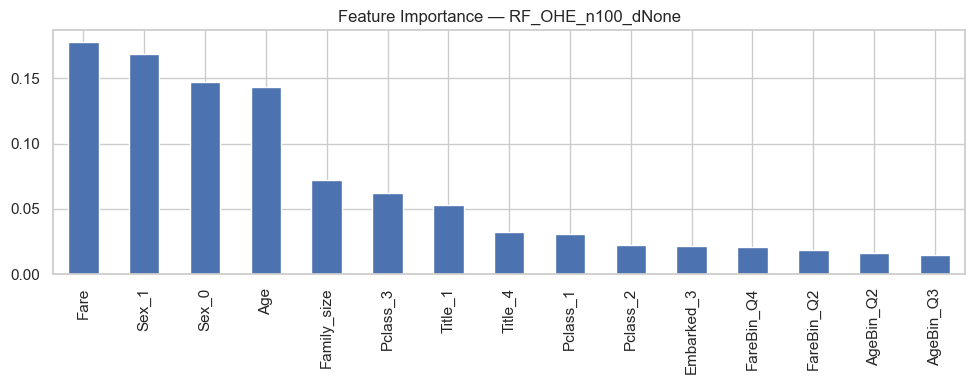

2026/03/28 14:19:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n100_dNone] cv_auc=0.8530 val_auc=0.8431  run_id=f26b8ef4137a47eea0da733386b33986


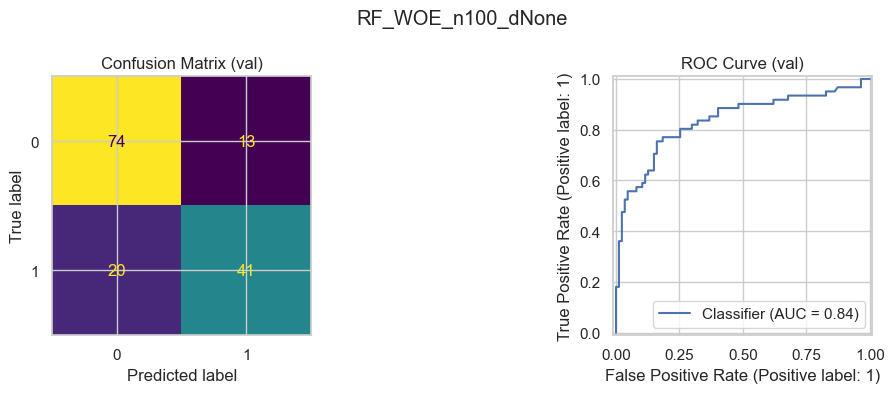

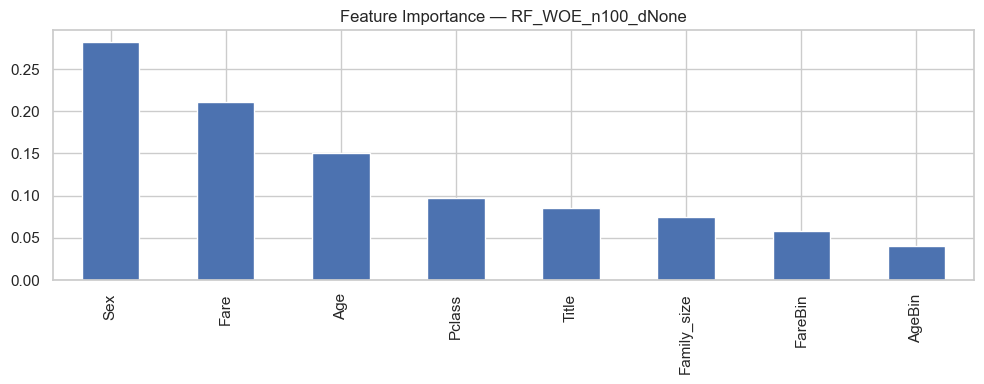

2026/03/28 14:19:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n100_dNone] cv_auc=0.8577 val_auc=0.8362  run_id=1b8fe126415a44b4a870a7496c201a9a


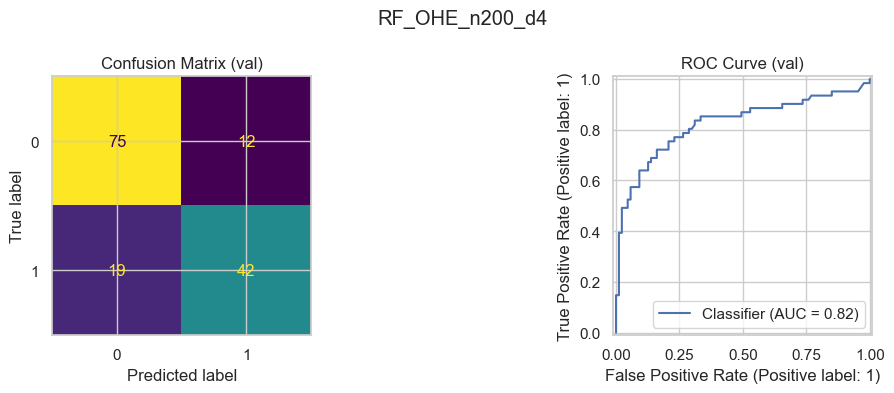

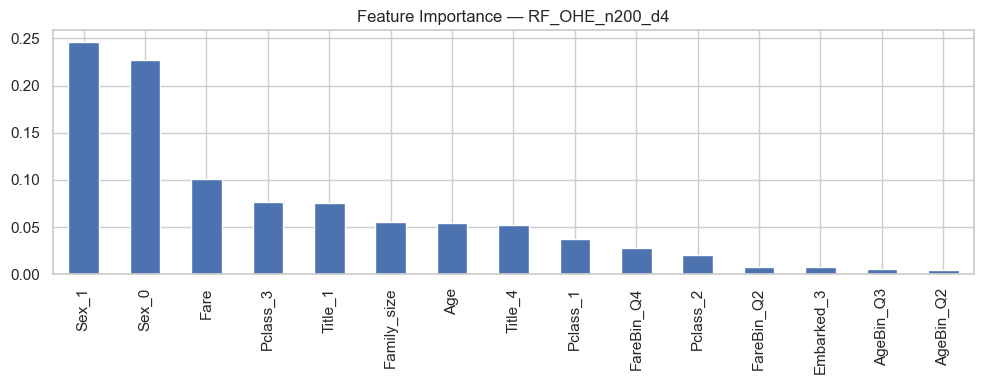

2026/03/28 14:19:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n200_d4] cv_auc=0.8550 val_auc=0.8236  run_id=3d399847552241adbc45b367310de555


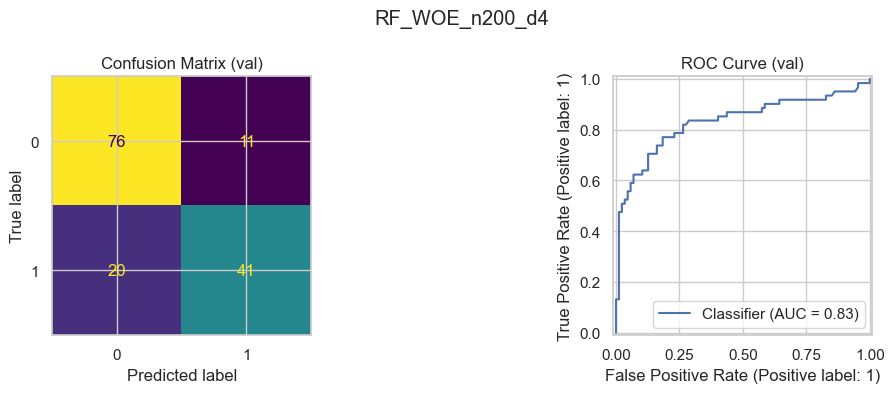

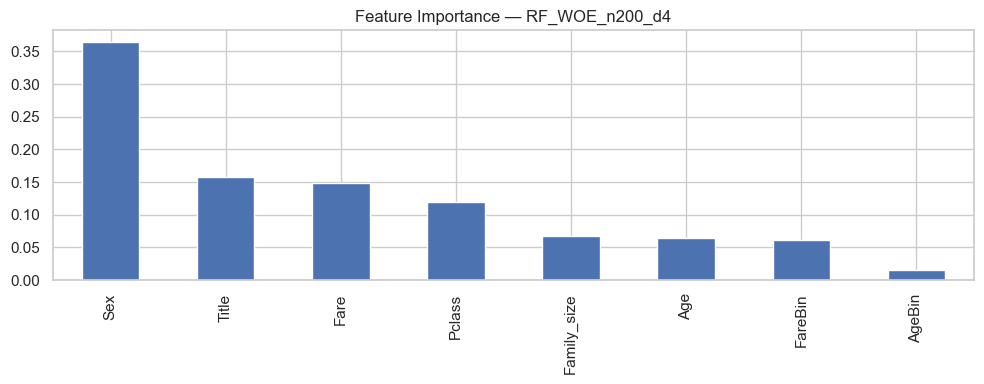

2026/03/28 14:19:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n200_d4] cv_auc=0.8582 val_auc=0.8322  run_id=0ee2081e37e245d2b11adbaf4fba7a7c


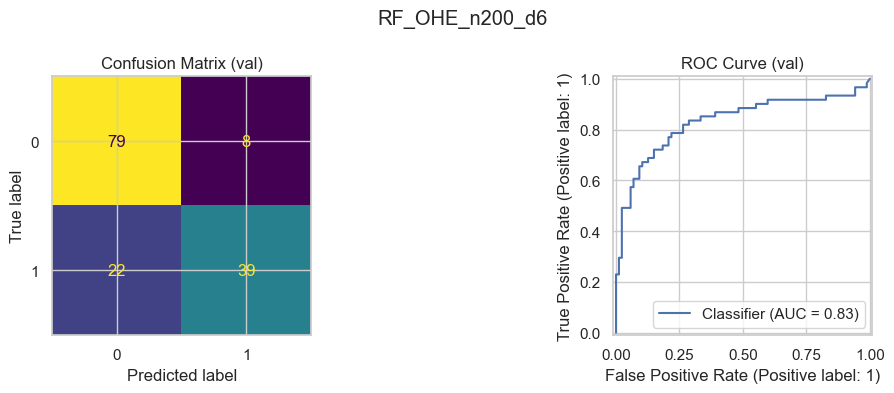

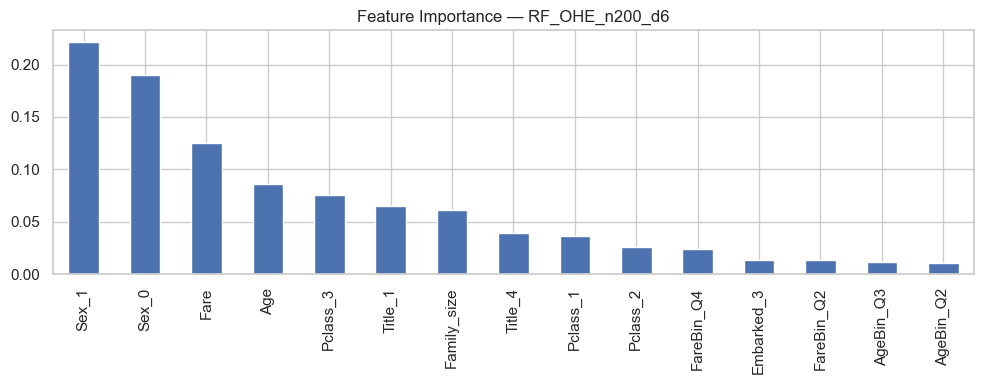

2026/03/28 14:19:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n200_d6] cv_auc=0.8549 val_auc=0.8322  run_id=ba0a47bc772e42f7b157a9b757cc9703


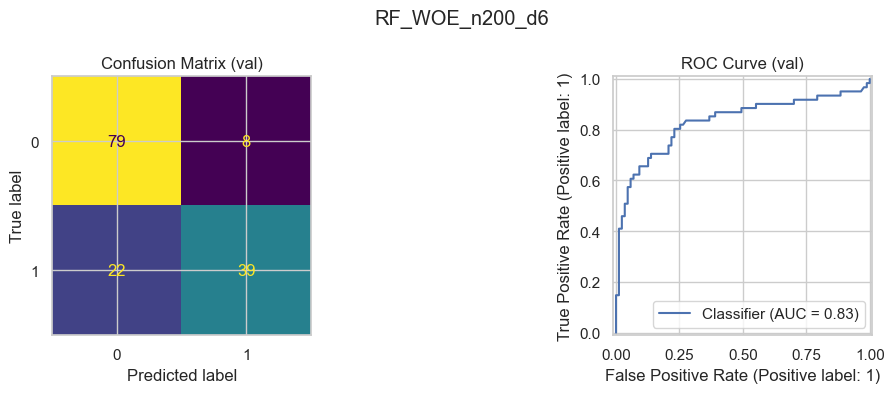

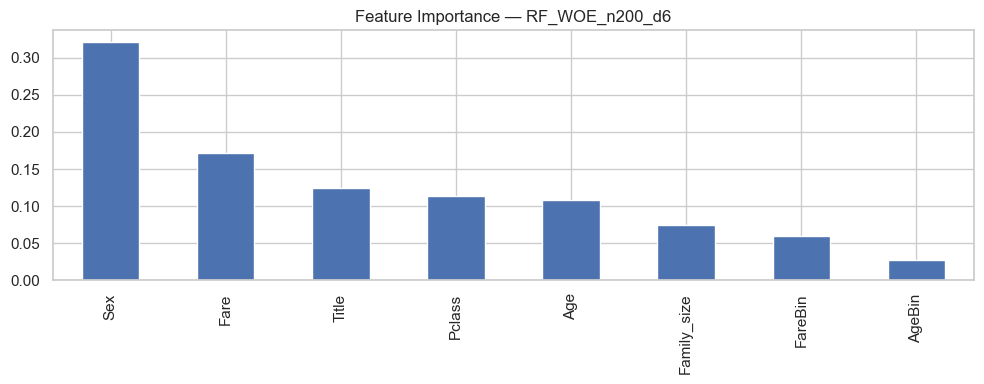

2026/03/28 14:19:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n200_d6] cv_auc=0.8613 val_auc=0.8315  run_id=8d751330b7034b03a56c4bfb39afd20e


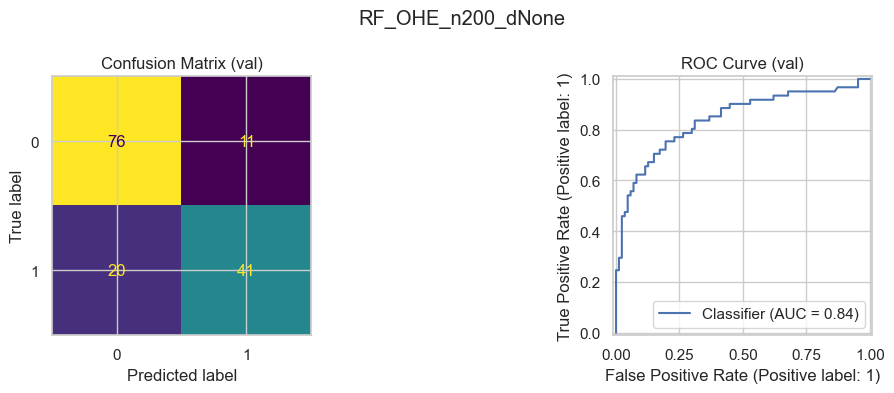

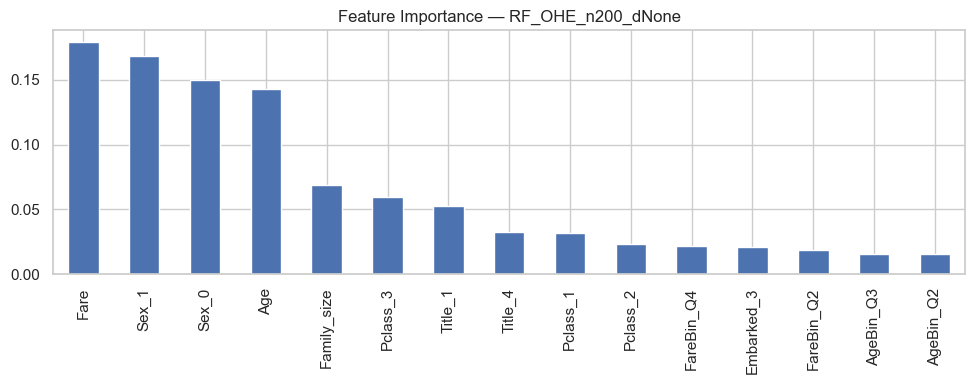

2026/03/28 14:19:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_OHE_n200_dNone] cv_auc=0.8515 val_auc=0.8407  run_id=ad4590d3b39c448daae2a9c79a268ee9


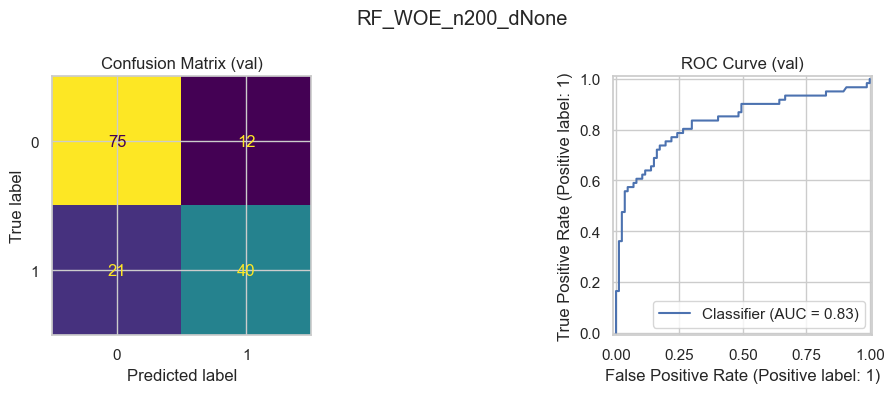

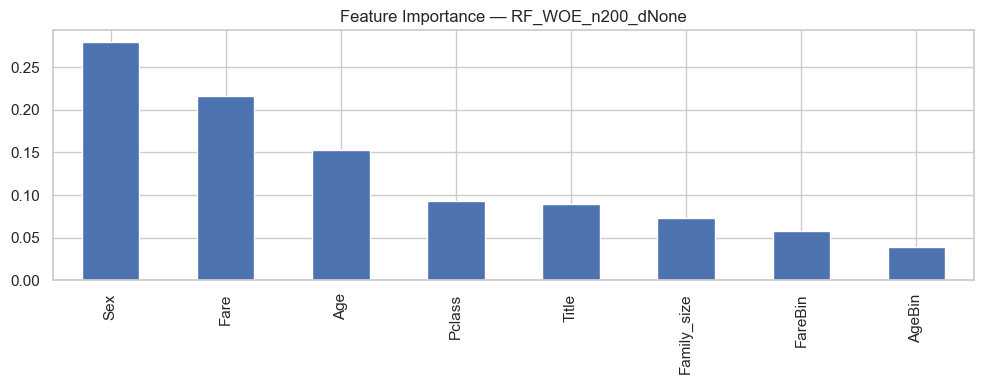

2026/03/28 14:19:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 14:19:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RF_WOE_n200_dNone] cv_auc=0.8565 val_auc=0.8322  run_id=1f889ba40cbd43028d2702c05a6a7579


In [18]:
for n_est in [50, 100, 200]:
    for max_depth in [4, 6, None]:
        rf = RandomForestClassifier(
            n_estimators=n_est, max_depth=max_depth,
            min_samples_leaf=2, random_state=42
        )
        results.append(log_run(
            f'RF_OHE_n{n_est}_d{max_depth}', rf,
            X_ohe_tr_sel, y_train, X_ohe_val_sel, y_val,
            'OHE', extra_params={'n_estimators': n_est, 'max_depth': str(max_depth)}
        ))
        results.append(log_run(
            f'RF_WOE_n{n_est}_d{max_depth}', rf,
            X_woe_tr_sel, y_train, X_woe_val_sel, y_val,
            'WOE', extra_params={'n_estimators': n_est, 'max_depth': str(max_depth)}
        ))

## Results Summary

In [ ]:
results_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['cv_acc', 'cv_auc', 'val_auc']):
    results_df.head(20).plot(x='run_name', y=metric, kind='bar', ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=80)
plt.show()

## Register Best Model

Selected by `val_auc`, retrained on train + val combined.

In [ ]:
best = results_df.iloc[0]
print('Best run:', best['run_name'], '| val_auc:', best['val_auc'])

best_encoding = 'OHE' if '_OHE_' in best['run_name'] else 'WOE'
X_tr_best  = X_ohe_tr_sel  if best_encoding == 'OHE' else X_woe_tr_sel
X_val_best = X_ohe_val_sel if best_encoding == 'OHE' else X_woe_val_sel

model_map = {
    'LR': lambda: Pipeline([('scaler', StandardScaler()),
                             ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))]),
    'RF': lambda: RandomForestClassifier(n_estimators=100, random_state=42),
}

model_key  = best['run_name'].split('_')[0]
best_model = model_map.get(model_key, model_map['RF'])()

X_full = pd.concat([X_tr_best, X_val_best], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train,   y_val],       axis=0).reset_index(drop=True)
best_model.fit(X_full.values.astype(float), y_full)

log_run(
    f'BEST_{best["run_name"]}',
    best_model,
    X_tr_best, y_train,
    X_val_best, y_val,
    best_encoding,
    register=True
)
print("Model registered as 'titanic-best-model' in MLflow Model Registry.")

In [ ]:
artifacts = {
    'best_run_id':   best['run_id'],
    'best_encoding': best_encoding,
    'selected_ohe':  selected_ohe,
    'selected_woe':  selected_woe,
    'woe_encoder':   woe_encoder,
    'numeric_cols':  NUMERIC_COLS,
    'cat_cols':      CAT_COLS,
    'woe_cols':      WOE_COLS,
    'ohe_source_cols': OHE_SOURCE_COLS,
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved. Best run_id:", best['run_id'])